In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/berlin_airbnb_cleaned.csv", encoding='utf-8')
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   index                  4999 non-null   int64  
 1   Review ID              4942 non-null   float64
 2   review_date            4942 non-null   str    
 3   Reviewer ID            4942 non-null   float64
 4   Reviewer Name          4942 non-null   str    
 5   Comments               4939 non-null   str    
 6   Listing ID             4999 non-null   int64  
 7   Listing URL            4999 non-null   str    
 8   Listing Name           4997 non-null   str    
 9   Host ID                4999 non-null   int64  
 10  Host URL               4999 non-null   str    
 11  Host Name              4998 non-null   str    
 12  Host Since             4998 non-null   str    
 13  Host Response Time     4366 non-null   str    
 14  Host Response Rate     4366 non-null   str    
 15  Is Superhost   

In [2]:
# Select only the relevant numerical columns for analysis
selected_numerical_cols = ['Price', 'Accomodates', 'Bedrooms', 'Beds', 'Min Nights']

# Calculate descriptive statistics (Mean, Median, Standard Deviation, Min, Max, etc.)
print("Global Descriptive Statistics for Numerical Features:")
df[selected_numerical_cols].describe()

Global Descriptive Statistics for Numerical Features:


,Price,Accomodates,Bedrooms,Beds,Min Nights
count,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000
mean,68.352270,3.111422,1.227846,1.911182,5.086017
std,54.042753,1.971432,0.713092,1.543718,14.825469
min,10.000000,1.000000,0.000000,0.000000,1.000000
25%,37.000000,2.000000,1.000000,1.000000,1.000000
50%,53.000000,2.000000,1.000000,1.000000,2.000000
75%,80.000000,4.000000,1.000000,2.000000,3.000000
max,888.000000,16.000000,8.000000,16.000000,240.000000


In [3]:
import pandas as pd
import numpy as np

# 1. Select only the numerical columns from the dataframe
numeric_cols = df.select_dtypes(include=[np.number]).columns

# 2. Calculate the Pearson correlation matrix
correlation_matrix = df[numeric_cols].corr()

# 3. Display the correlation of all numerical features with 'Price', sorted in descending order
print("Correlation of numerical variables with Price:")
print(correlation_matrix['Price'].sort_values(ascending=False))

Correlation of numerical variables with Price:
Price                   1.000000
Accomodates             0.661326
Bedrooms                0.612926
Guests Included         0.575431
Beds                    0.542931
Bathrooms               0.389049
Cleanliness Rating      0.093599
Location Rating         0.085731
Overall Rating          0.038449
Latitude                0.031134
Reviews                 0.025068
Accuracy Rating         0.005616
Review ID               0.005542
Communication Rating   -0.003693
Host ID                -0.007547
Checkin Rating         -0.014833
Min Nights             -0.016968
Listing ID             -0.017292
index                  -0.030642
Longitude              -0.034425
Reviewer ID            -0.116900
Value Rating           -0.135367
Name: Price, dtype: float64


In [4]:
# 1. Analyze the relationship between Room Type and Price
print("Price Statistics by Room Type:")
room_stats = df.groupby('Room Type')['Price'].agg(['mean', 'median', 'std', 'count'])
print(room_stats.sort_values(by='mean', ascending=False))

print("\n" + "="*50 + "\n")

# 2. Analyze the relationship between Neighborhood Group and Price
print("Price Statistics by Neighborhood Group:")
neighborhood_stats = df.groupby('Neighborhood Group')['Price'].agg(['mean', 'median', 'std', 'count'])
print(neighborhood_stats.sort_values(by='mean', ascending=False))

Price Statistics by Room Type:
                      mean  median        std  count
Room Type                                           
Entire home/apt  93.699051    76.0  62.418203   2635
Private room     40.203132    38.0  17.504173   2299
Shared room      36.446154    25.0  28.031807     65


Price Statistics by Neighborhood Group:
                               mean  median        std  count
Neighborhood Group                                           
Mitte                     79.730171    64.0  60.043003   1286
Pankow                    71.676906    55.0  52.612135    879
Tempelhof - SchÃ¶neberg   68.100977    52.0  56.978435    307
Friedrichshain-Kreuzberg  66.355241    50.0  53.622833   1202
Charlottenburg-Wilm.      65.543417    52.0  55.172166    357
NeukÃ¶lln                 56.994526    44.0  43.811107    548
Steglitz - Zehlendorf     52.275362    42.0  27.794352     69
Treptow - KÃ¶penick       51.695238    41.0  41.484502    105
Lichtenberg               51.200000    39.

In [5]:
# Convert categorical text columns into numerical dummy variables (0 and 1)
df_encoded = pd.get_dummies(df, columns=['Room Type', 'Neighborhood Group'], drop_first=False)

# Filter and select only the newly created dummy columns and the 'Price' column
encoded_cols = [col for col in df_encoded.columns if 'Room Type_' in col or 'Neighborhood Group_' in col]
encoded_cols.append('Price')

# Calculate the correlation matrix specifically for these categorical-derived features with Price
correlation_categorical = df_encoded[encoded_cols].corr()

# Display the correlation results sorted in descending order
print("Correlation of Categorical Features (One-Hot Encoded) with Price:")
print(correlation_categorical['Price'].sort_values(ascending=False))

Correlation of Categorical Features (One-Hot Encoded) with Price:
Price                                          1.000000
Room Type_Entire home/apt                      0.495217
Neighborhood Group_Mitte                       0.123916
Neighborhood Group_Pankow                      0.028418
Neighborhood Group_Tempelhof - SchÃ¶neberg    -0.001190
Neighborhood Group_Charlottenburg-Wilm.       -0.014415
Neighborhood Group_Spandau                    -0.020293
Neighborhood Group_Friedrichshain-Kreuzberg   -0.020793
Neighborhood Group_Marzahn - Hellersdorf      -0.026177
Neighborhood Group_Steglitz - Zehlendorf      -0.035197
Neighborhood Group_Treptow - KÃ¶penick        -0.045151
Neighborhood Group_Lichtenberg                -0.054861
Neighborhood Group_Reinickendorf              -0.058379
Room Type_Shared room                         -0.067770
Neighborhood Group_NeukÃ¶lln                  -0.073750
Room Type_Private room                        -0.480683
Name: Price, dtype: float64


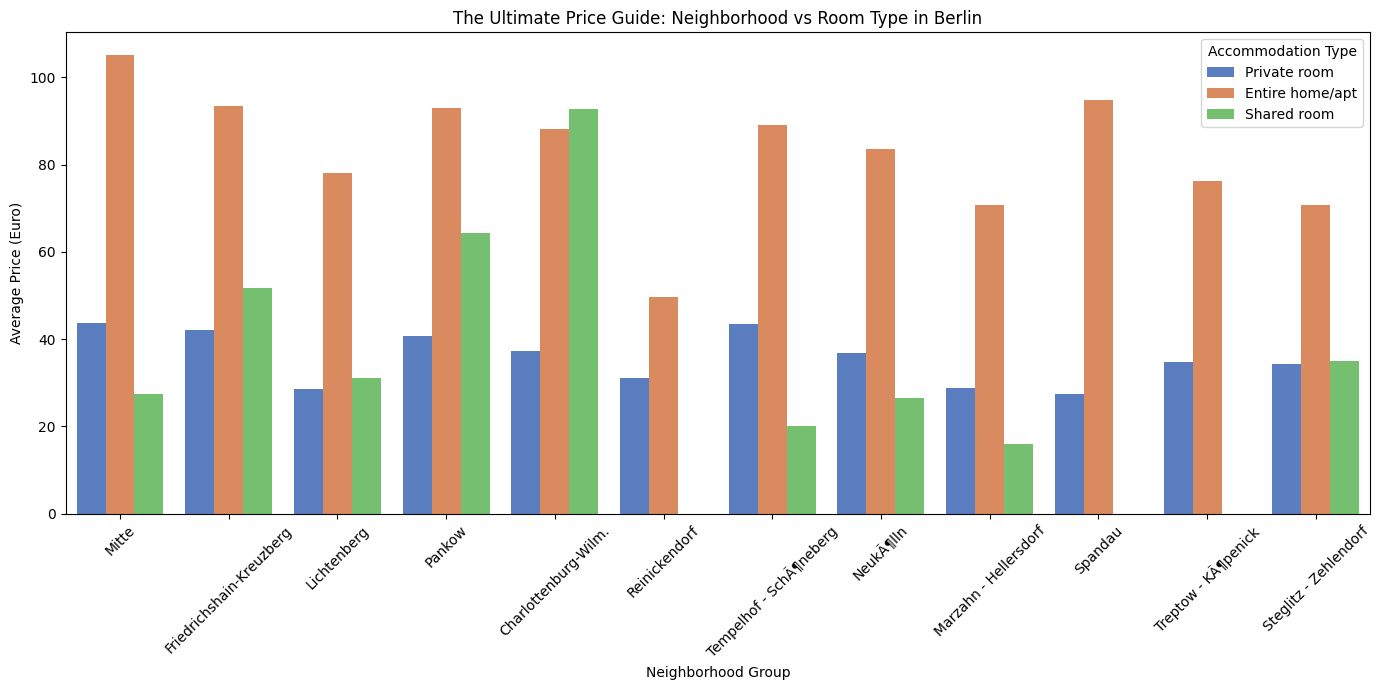

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grouped Barplot: Comparing Room Type Prices across different Neighborhoods
plt.figure(figsize=(14, 7))

# We use 'hue' to split each neighborhood into Entire home vs Private room
# This answers the ultimate business question for the project
sns.barplot(x='Neighborhood Group', y='Price', hue='Room Type', data=df, errorbar=None, palette='muted')

plt.xticks(rotation=45)
plt.title('The Ultimate Price Guide: Neighborhood vs Room Type in Berlin')
plt.xlabel('Neighborhood Group')
plt.ylabel('Average Price (Euro)')
plt.legend(title='Accommodation Type', loc='upper right')
plt.tight_layout()
plt.show()

In [4]:
print(df.columns.tolist())

['index', 'Review ID', 'review_date', 'Reviewer ID', 'Reviewer Name', 'Comments', 'Listing ID', 'Listing URL', 'Listing Name', 'Host ID', 'Host URL', 'Host Name', 'Host Since', 'Host Response Time', 'Host Response Rate', 'Is Superhost', 'neighbourhood', 'Neighborhood Group', 'City', 'Postal Code', 'Country Code', 'Country', 'Latitude', 'Longitude', 'Is Exact Location', 'Property Type', 'Room Type', 'Accomodates', 'Bathrooms', 'Bedrooms', 'Beds', 'Price', 'Guests Included', 'Min Nights', 'Reviews', 'First Review', 'Last Review', 'Overall Rating', 'Accuracy Rating', 'Cleanliness Rating', 'Checkin Rating', 'Communication Rating', 'Location Rating', 'Value Rating', 'Instant Bookable', 'Business Travel Ready']


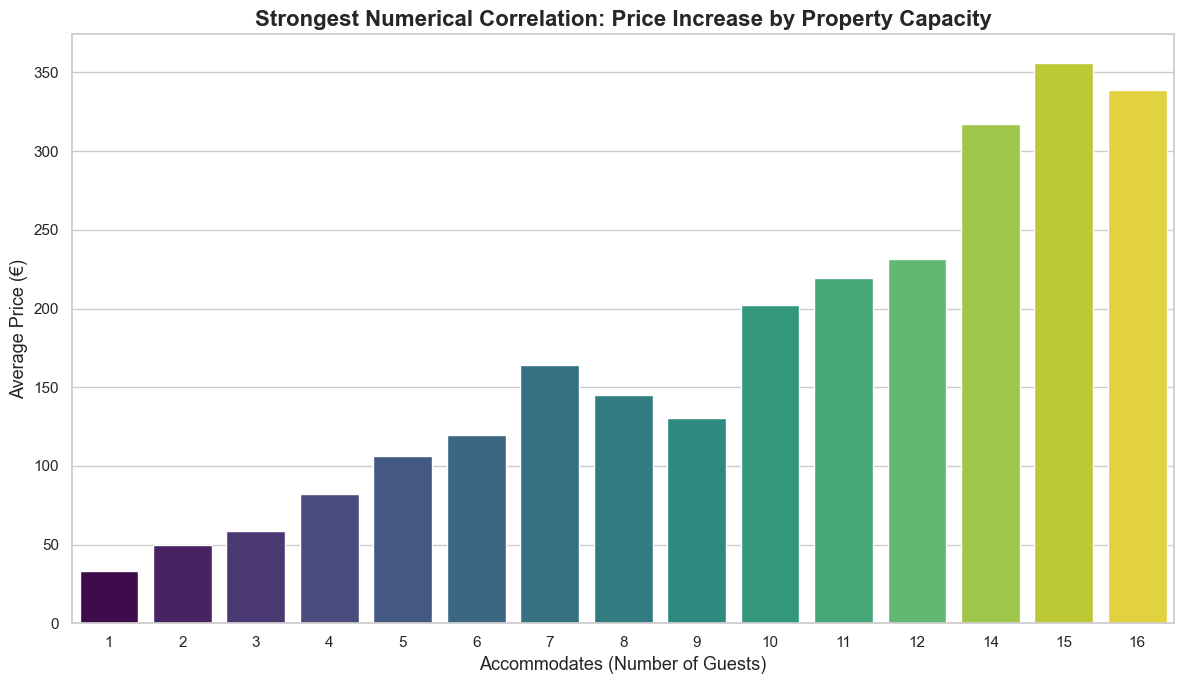

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style
sns.set_theme(style="whitegrid")

# Create a bar plot showing average Price for each Accommodates value
plt.figure(figsize=(12, 7))
sns.barplot(x='Accomodates', y='Price', data=df, errorbar=None, hue='Accomodates', palette='viridis', legend=False)

# Add descriptive titles and labels in English
plt.title('Strongest Numerical Correlation: Price Increase by Property Capacity', fontsize=16, fontweight='bold')
plt.xlabel('Accommodates (Number of Guests)', fontsize=13)
plt.ylabel('Average Price (€)', fontsize=13)

# Show the plot
plt.tight_layout()
plt.show()

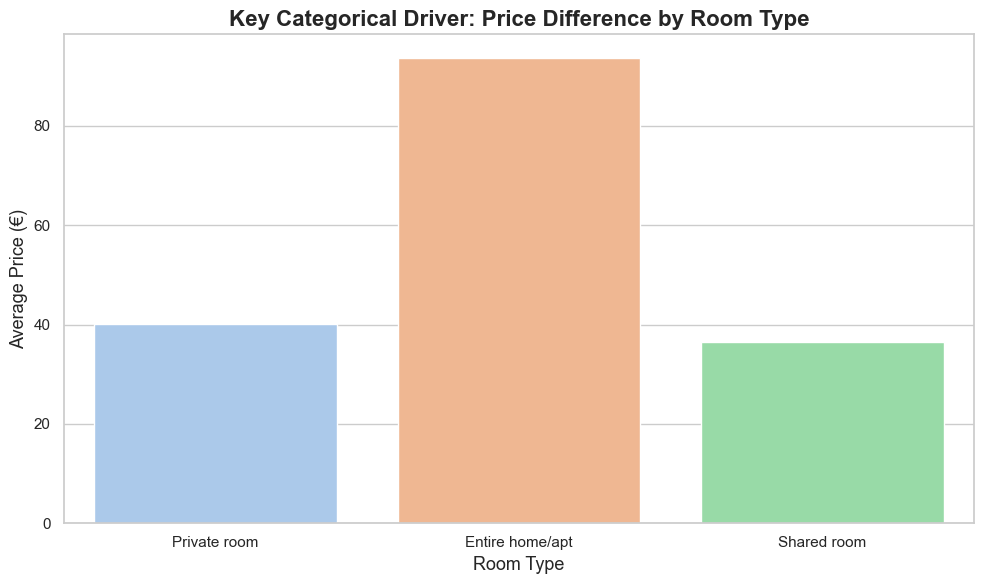

In [9]:
# Create a bar plot showing average Price for each Room Type
plt.figure(figsize=(10, 6))
sns.barplot(x='Room Type', y='Price', data=df, errorbar=None, hue='Room Type', palette='pastel', legend=False)

# Add descriptive titles and labels in English
plt.title('Key Categorical Driver: Price Difference by Room Type', fontsize=16, fontweight='bold')
plt.xlabel('Room Type', fontsize=13)
plt.ylabel('Average Price (€)', fontsize=13)

# Show the plot
plt.tight_layout()
plt.show()

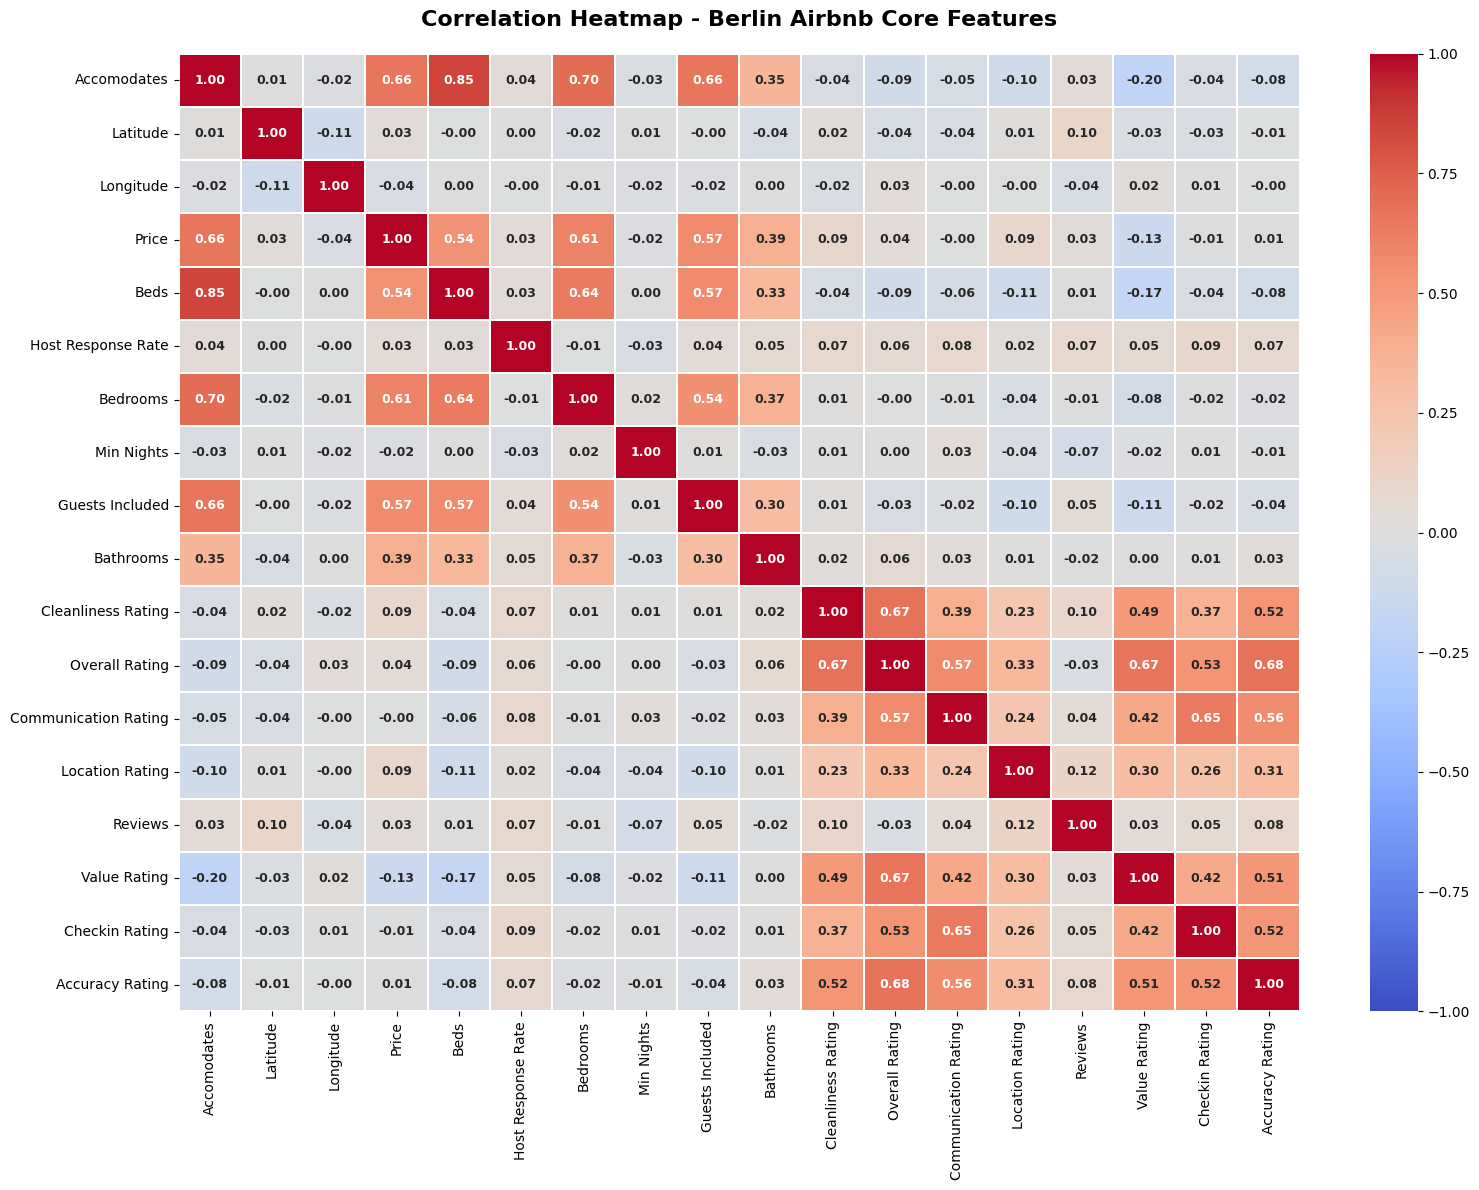

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the specific EDA dataset (46 columns)
df_original = pd.read_csv('../data/processed/berlin_airbnb_cleaned_EDA.csv')

# 🔥 FIX: Clean 'Host Response Rate' if it contains the '%' sign
if 'Host Response Rate' in df_original.columns:
    # Convert to string first, remove '%', convert to numeric, and replace errors with NaN
    df_original['Host Response Rate'] = df_original['Host Response Rate'].astype(str).str.replace('%', '')
    df_original['Host Response Rate'] = pd.to_numeric(df_original['Host Response Rate'], errors='coerce')
    # Fill any missing values with the median
    df_original['Host Response Rate'] = df_original['Host Response Rate'].fillna(df_original['Host Response Rate'].median())

# 2. Define the exact features from your group member's chart
exact_features = [
    'Accomodates', 'Latitude', 'Longitude', 'Price', 'Beds', 'Host Response Rate', 
    'Bedrooms', 'Min Nights', 'Guests Included', 'Bathrooms', 'Cleanliness Rating', 
    'Overall Rating', 'Communication Rating', 'Location Rating', 'Reviews', 
    'Value Rating', 'Checkin Rating', 'Accuracy Rating'
]

# Filter and build the matrix safely
df_heatmap = df_original[exact_features]
corr_matrix = df_heatmap.corr()

# 3. Plot the Heatmap
plt.figure(figsize=(16, 12)) 
sns.heatmap(corr_matrix, 
            annot=True,         # Shows the numbers inside the squares
            cmap='coolwarm',    # Professional red-to-blue palette
            fmt=".2f",          # Two decimal places
            linewidths=0.3,     
            annot_kws={"size": 9, "weight": "bold"}, 
            vmin=-1, vmax=1)    

plt.title('Correlation Heatmap - Berlin Airbnb Core Features', fontsize=16, pad=20, weight='bold')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

# Save the perfect image to your visuals folder
plt.savefig('../visuals/exact_matched_correlation_heatmap.png', dpi=300)
plt.show()

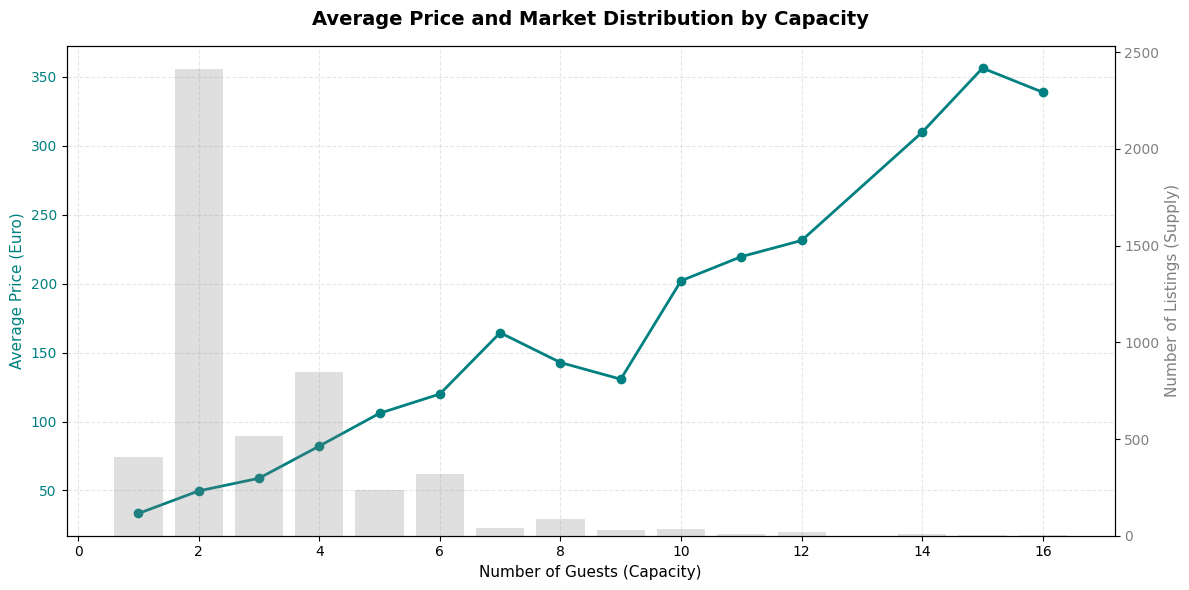

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the cleaned dataset directly from the processed folder
df_original = pd.read_csv('../data/processed/berlin_airbnb_cleaned_EDA.csv')

# 2. Dynamically find the correct column names to avoid spelling errors
price_col = next((c for c in df_original.columns if c.lower().strip() == 'price'), 'Price')
accommodates_col = next((c for c in df_original.columns if 'accommodat' in c.lower() or 'accomodat' in c.lower()), None)

if accommodates_col and price_col:
    # 3. Calculate average price and listing counts grouped by capacity
    price_by_capacity = df_original.groupby(accommodates_col)[price_col].mean().sort_index()
    capacity_distribution = df_original[accommodates_col].value_counts().sort_index()

    # 4. Create the dual-axis chart
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot the Average Price trend (Line chart on the Left Y-axis)
    ax1.plot(price_by_capacity.index, price_by_capacity.values, color='teal', marker='o', linewidth=2, label='Average Price')
    ax1.set_xlabel('Number of Guests (Capacity)', fontsize=11)
    ax1.set_ylabel('Average Price (Euro)', color='teal', fontsize=11)
    ax1.tick_params(axis='y', labelcolor='teal')
    ax1.grid(True, linestyle='--', alpha=0.3) # Adds a clean background grid

    # Plot the Market Supply / Number of listings (Bar chart on the Right Y-axis)
    ax2 = ax1.twinx()
    ax2.bar(capacity_distribution.index, capacity_distribution.values, alpha=0.25, color='gray', label='Number of Listings')
    ax2.set_ylabel('Number of Listings (Supply)', color='gray', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='gray')

    # Title and layout settings
    plt.title('Average Price and Market Distribution by Capacity', fontsize=14, pad=15, weight='bold')
    fig.tight_layout()

    # Save the professional figure directly into your visuals folder
    plt.savefig('../visuals/price_capacity_distribution.png', dpi=300)

    plt.show()
else:
    print("Error: Could not find 'Price' or 'Accommodates' columns in the dataset.")

In [20]:
import pandas as pd
import numpy as np

# 1. Load the raw dataset to recover the original text columns (like neighbourhood names)
try:
    df_raw = pd.read_csv('../data/raw/berlin_airbnb.csv')
except:
    df_raw = pd.read_csv('../data/berlin_airbnb.csv')

# 2. Load your current ML dataset to use as a master filter for rows
df_ml = pd.read_csv('../data/processed/berlin_airbnb_cleaned_ML.csv')

# 3. Drop 'Square Feet' and other completely messy columns from the raw data immediately
bad_cols = ['Square Feet', 'square_feet', 'id', 'listing_url', 'scrape_id', 'last_scraped', 'name']
df_raw_filtered = df_raw.drop(columns=[c for c in bad_cols if c in df_raw.columns], errors='ignore')

# 4. Keep ONLY the rows that match your final cleaned ML dataset
# We use the index to align them perfectly
df_eda_perfect = df_raw_filtered.iloc[df_ml.index].copy()

# 5. Quick clean of the core numericals in this perfectly sliced dataset
if 'Price' in df_eda_perfect.columns and df_eda_perfect['Price'].dtype == 'object':
    df_eda_perfect['Price'] = df_eda_perfect['Price'].str.replace('$', '').str.replace(',', '').astype(float)
elif 'price' in df_eda_perfect.columns and df_eda_perfect['price'].dtype == 'object':
    df_eda_perfect['price'] = df_eda_perfect['price'].str.replace('$', '').str.replace(',', '').astype(float)

# Fill remaining core missing fields with median/mode based on the filtered rows
for col in df_eda_perfect.columns:
    if df_eda_perfect[col].dtype in ['int64', 'float64']:
        df_eda_perfect[col] = df_eda_perfect[col].fillna(df_eda_perfect[col].median())

# 6. Save both datasets separately in the processed data folder
# Save the 46-column version for EDA and visualizations
df_eda_perfect.to_csv('../data/processed/berlin_airbnb_cleaned_EDA.csv', index=False)

# Save the final encoded version for Machine Learning models
df_ml.to_csv('../data/processed/berlin_airbnb_cleaned_ML.csv', index=False)

print(f"🎯 Success! Datasets synchronized and saved perfectly.")
print(f"Rows in ML: {df_ml.shape[0]}  |  Rows in EDA: {df_eda_perfect.shape[0]}")

🎯 Success! Datasets synchronized and saved perfectly.
Rows in ML: 4970  |  Rows in EDA: 4970


In [21]:
# 1. Load the newly created EDA dataset
df_proof = pd.read_csv('../data/processed/berlin_airbnb_cleaned_EDA.csv')

# 2. Check the dimensions (Rows and Columns)
print("--- DIMENSIONS OF THE NEW DATASET ---")
print(f"Rows (Rreshta): {df_proof.shape[0]}")
print(f"Columns (Kolona): {df_proof.shape[1]}")

# 3. Show the first 5 rows to see how it looks
print("\n--- FIRST 5 ROWS ---")
print(df_proof[['Price', 'Accomodates', 'neighbourhood']].head())

--- DIMENSIONS OF THE NEW DATASET ---
Rows (Rreshta): 4970
Columns (Kolona): 46

--- FIRST 5 ROWS ---
   Price  Accomodates   neighbourhood
0   70.0            2         Wedding
1   59.0            2  Friedrichshain
2   40.0            2       Fennpfuhl
3   45.0            2  Friedrichshain
4  125.0            4       Kreuzberg
